# Baseline ML: Metadata Risk Prediction
Using patient metadata to predict high-risk vs low-risk lesions. The prompt asks for binary classifiers prioritizing sensitivity.

Let's define Malignant/Cancer vs Benign:
- Benign: `nv`, `bkl`, `df`, `vasc`
- Malignant: `mel`, `bcc`, `akiec`

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

## Load and Prepare Data

In [2]:
df = pd.read_csv('../archive/HAM10000_metadata.csv')
df['age'] = df['age'].fillna(df['age'].median())

# Binary target:
malignant_classes = ['mel', 'bcc', 'akiec']
df['target'] = df['dx'].apply(lambda x: 1 if x in malignant_classes else 0)

print('Class distribution:\n', df['target'].value_counts())

Class distribution:
 target
0    8061
1    1954
Name: count, dtype: int64


## Feature Engineering
We only use metadata: `age`, `sex`, `localization`.

In [3]:
X = df[['age', 'sex', 'localization']]
y = df['target']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Model Pipeline

In [4]:
categorical_features = ['sex', 'localization']
numeric_features = ['age']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Logistic Regression with Class Weight to prioritize sensitivity
clf_lr = Pipeline(steps=[('preprocessor', preprocessor),
                         ('classifier', LogisticRegression(class_weight='balanced', random_state=42))])

clf_lr.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sex', 'localization'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

## Evaluation

Logistic Regression Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.92      0.71      0.80      1612
Malignant (1)       0.38      0.74      0.50       391

     accuracy                           0.72      2003
    macro avg       0.65      0.73      0.65      2003
 weighted avg       0.81      0.72      0.74      2003



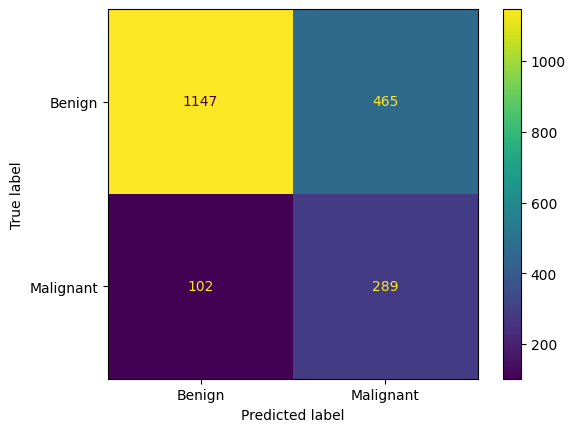

In [5]:
y_pred_lr = clf_lr.predict(X_test)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Benign (0)', 'Malignant (1)']))

cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
disp.plot()
plt.show()

Notice how adding `class_weight='balanced'` hugely impacts Recall/Sensitivity for the Malignant class.